<a href="https://colab.research.google.com/github/anjitha2002/google-stock-Price-prediction-using-LSTM/blob/main/google_stock_Price_prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers,models

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
data=pd.read_csv("/content/GOOG.csv")

In [5]:
data

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.470,713.1200,716.48,1306065,718.27,722.470,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.980,717.3100,719.00,1214517,718.92,722.980,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.650,703.2600,714.91,1982471,710.36,716.650,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.820,688.4515,708.65,3402357,691.72,708.820,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.480,693.4100,698.77,2082538,693.71,702.480,693.4100,698.77,2082538,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,GOOG,2021-06-07 00:00:00+00:00,2466.09,2468.000,2441.0725,2451.32,1192453,2466.09,2468.000,2441.0725,2451.32,1192453,0.0,1.0
1254,GOOG,2021-06-08 00:00:00+00:00,2482.85,2494.495,2468.2400,2479.90,1253253,2482.85,2494.495,2468.2400,2479.90,1253253,0.0,1.0
1255,GOOG,2021-06-09 00:00:00+00:00,2491.40,2505.000,2487.3300,2499.50,1006337,2491.40,2505.000,2487.3300,2499.50,1006337,0.0,1.0
1256,GOOG,2021-06-10 00:00:00+00:00,2521.60,2523.260,2494.0000,2494.01,1561733,2521.60,2523.260,2494.0000,2494.01,1561733,0.0,1.0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB


In [7]:
data.isnull().sum()

,0
symbol,0
date,0
close,0
high,0
low,0
open,0
volume,0
adjClose,0
adjHigh,0
adjLow,0


In [8]:
data1=data[['close']]

In [9]:
data1

,close
0,718.27
1,718.92
2,710.36
3,691.72
4,693.71
...,...
1253,2466.09
1254,2482.85
1255,2491.40
1256,2521.60


In [10]:
import matplotlib.pyplot as plt

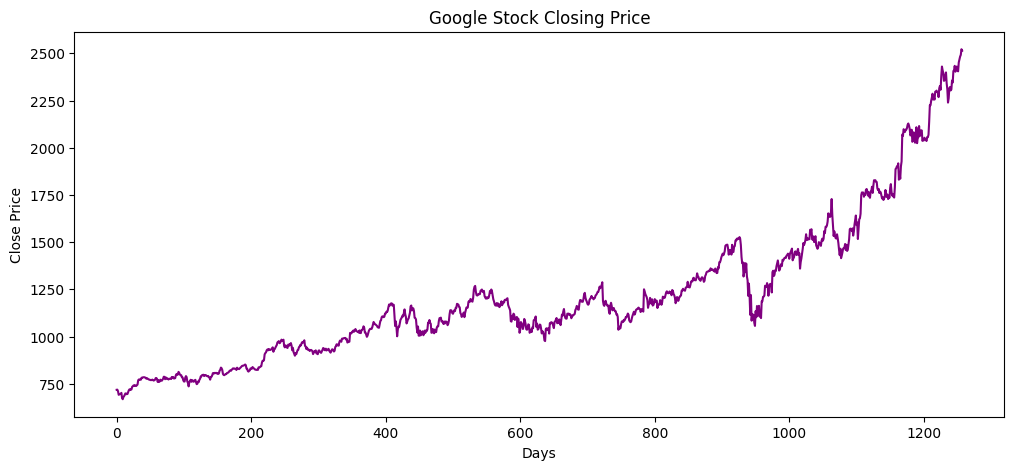

In [11]:
plt.figure(figsize=(12,5))

plt.plot(data1['close'],color='purple')

plt.title('Google Stock Closing Price')
plt.xlabel('Days')
plt.ylabel('Close Price')

plt.show()

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data1.values)

In [14]:
timestep=60
x=[]
y=[]

for i in range(timestep,len(scaled_data)):
  x.append(scaled_data[i-timestep:i,0])
  y.append(scaled_data[i,0])

x=np.array(x)
y=np.array(y)

In [15]:
x=x.reshape(x.shape[0],x.shape[1],1)

In [16]:
x

array([[[0.02698372],
        [0.02733443],
        [0.02271575],
        ...,
        [0.05568325],
        [0.06033432],
        [0.06048   ]],

       [[0.02733443],
        [0.02271575],
        [0.01265823],
        ...,
        [0.06033432],
        [0.06048   ],
        [0.05776598]],

       [[0.02271575],
        [0.01265823],
        [0.01373196],
        ...,
        [0.06048   ],
        [0.05776598],
        [0.04931637]],

       ...,

       [[0.75443793],
        [0.76848285],
        [0.76770587],
        ...,
        [0.96231668],
        [0.97004867],
        [0.9790918 ]],

       [[0.76848285],
        [0.76770587],
        [0.73810526],
        ...,
        [0.97004867],
        [0.9790918 ],
        [0.98370509]],

       [[0.76770587],
        [0.73810526],
        [0.74187143],
        ...,
        [0.9790918 ],
        [0.98370509],
        [1.        ]]])

In [17]:
print(x.shape)

(1198, 60, 1)


In [18]:
print(y.shape)

(1198,)


In [19]:
# split data for training and testing

from sklearn.model_selection import train_test_split

In [20]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,shuffle=False
)

In [21]:
print(x_train.shape)
print(x_test.shape)

(958, 60, 1)
(240, 60, 1)


In [22]:
model=models.Sequential([

    layers.LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1)),
    layers.Dropout(0.2),
    layers.LSTM(units=50,return_sequences=False),
    layers.Dropout(0.2),

    # classification output
    layers.Dense(units=1)
],name="Stock-prediction")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()

Model: "Stock-prediction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# model compile

model.compile(optimizer="adam",
              loss='mean_squared_error',
              metrics=['mae'])

In [25]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1

    )

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0117 - mae: 0.0769 - val_loss: 0.0149 - val_mae: 0.1047
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - mae: 0.0319 - val_loss: 0.0038 - val_mae: 0.0517
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - mae: 0.0238 - val_loss: 0.0027 - val_mae: 0.0414
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - mae: 0.0241 - val_loss: 0.0026 - val_mae: 0.0411
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0010 - mae: 0.0234 - val_loss: 0.0015 - val_mae: 0.0313
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7625e-04 - mae: 0.0233 - val_loss: 0.0014 - val_mae: 0.0299
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9993e-04 - mae: 0.0222 - val_loss: 0.0015 - val_mae: 0.0310
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.1283e-04 - mae: 0.0223 - val_loss: 0.0015 - val_mae: 0.0305
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step -

In [26]:
loss,accuracy=model.evaluate(x_test,y_test)
print("Test accuracy",accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - mae: 0.0342     
Test accuracy 0.03417152538895607


In [27]:
prediction=model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [28]:
print(prediction)

[[0.39959222]
 [0.39496946]
 [0.3943612 ]
 [0.39838627]
 [0.4071412 ]
 [0.41653574]
 [0.42591506]
 [0.4351588 ]
 [0.44553804]
 [0.45233425]
 [0.4568357 ]
 [0.45859724]
 [0.45878237]
 [0.45768672]
 [0.46022752]
 [0.46367794]
 [0.46799928]
 [0.46752322]
 [0.46407497]
 [0.4608988 ]
 [0.45568255]
 [0.45195878]
 [0.45037836]
 [0.44614485]
 [0.44042638]
 [0.43391666]
 [0.42867938]
 [0.42719737]
 [0.42766613]
 [0.4294446 ]
 [0.43046567]
 [0.43320578]
 [0.43753234]
 [0.44126335]
 [0.44502544]
 [0.45170593]
 [0.45806366]
 [0.46628255]
 [0.47413677]
 [0.48125136]
 [0.48853314]
 [0.49858797]
 [0.5069377 ]
 [0.5138868 ]
 [0.51786935]
 [0.52177227]
 [0.53089666]
 [0.5335009 ]
 [0.52751404]
 [0.51225966]
 [0.49618077]
 [0.47969037]
 [0.46453997]
 [0.4523773 ]
 [0.44572952]
 [0.44161794]
 [0.43767145]
 [0.4316359 ]
 [0.42310393]
 [0.4174216 ]
 [0.41012764]
 [0.4043103 ]
 [0.4016658 ]
 [0.40297952]
 [0.40692824]
 [0.4119958 ]
 [0.418797  ]
 [0.42299518]
 [0.42748746]
 [0.4286905 ]
 [0.42844436]
 [0.42

In [29]:
predicted=scaler.inverse_transform(prediction)
actual=scaler.inverse_transform(y_test.reshape(-1,1))

In [30]:
print(predicted.shape)

(240, 1)


In [31]:
print(actual.shape)

(240, 1)


In [32]:
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(actual,predicted)
print("MSE:",mse)
rmse=np.sqrt(mse)
print("RMSE:",rmse)

MSE: 6639.550644176751
RMSE: 81.48343785197548


In [33]:
import matplotlib.pyplot as plt

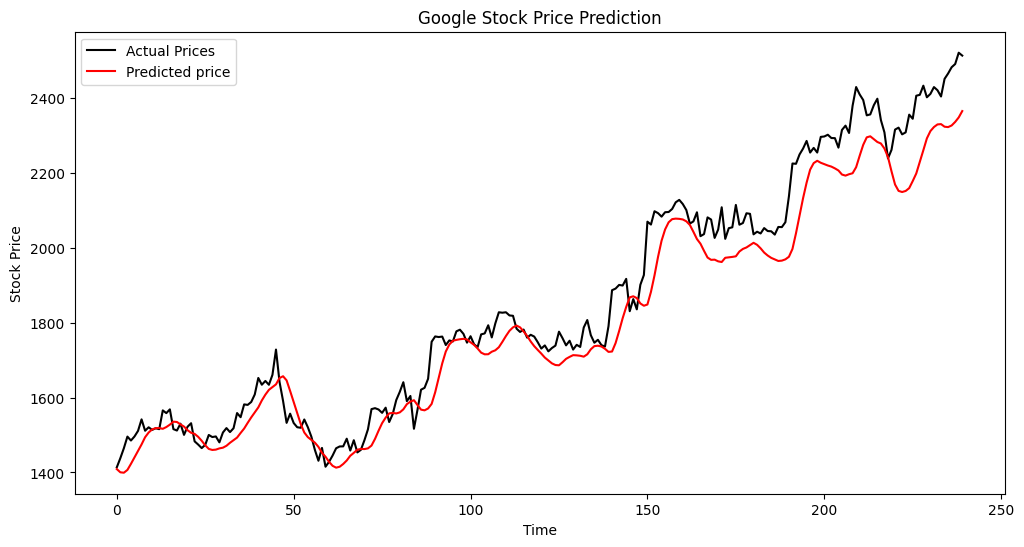

In [34]:


plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual Prices', color='black')
plt.plot(predicted, label='Predicted price', color='red')
plt.legend()
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.show()

